# Introdución á detección de obxectos con PyTorch

A detección de obxectos é unha tarefa de visión por computador que consiste en localizar obxectos nunha imaxe mediante caixas delimitadoras (bounding boxes) e clasificalos en base a unha serie de categorías predefinidas. Neste caderno imos aprender os conceptos básicos da detección de obxectos usando PyTorch e torchvision.

Nesta práctica imos traballar con detectores de obxectos clásicos. O obxectivo é entender como funcionan estes detectores e como se poden empregar para identificar obxectos en imaxes. O dataset que imos empregar é un subconxunto do Human Faces Object Detection Dataset (https://www.kaggle.com/datasets/sbaghbidi/human-faces-object-detection), no que cada imaxe contén un único obxecto (unha cara humana).

Imos a cargar varias imaxes de exemplo e visualizar as caixas delimitadoras que indican a posición das caras nas imaxes.

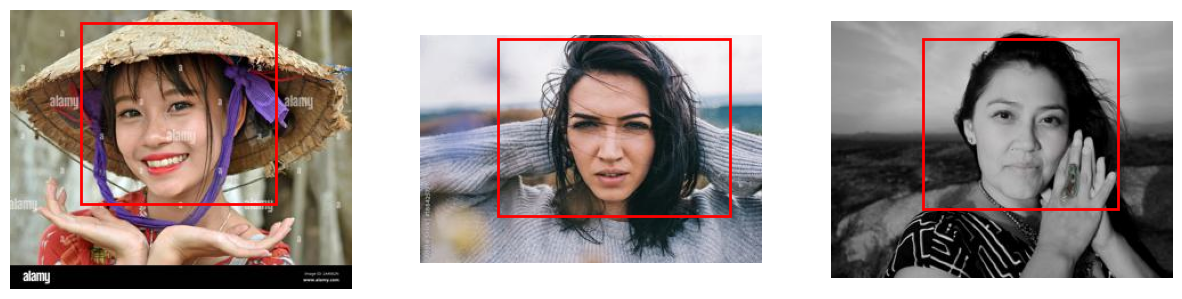

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

dataset_path = Path("human-faces-object-detection-subset")
images_path = dataset_path / "images"
images_list = list(images_path.glob("*.jpg"))
annotations = pd.read_csv(dataset_path / "faces.csv")


n = 3
image_random_paths = random.sample(images_list, n)
fig, ax = plt.subplots(nrows=1, ncols=n,figsize=(15, 5))

for i, example_image_path in enumerate(image_random_paths):
    example_image_annotations = annotations[annotations["image_name"] == example_image_path.name]
    bboxes = example_image_annotations[["x0", "y0", "x1", "y1"]].values

    image = Image.open(example_image_path)
    ax[i].imshow(image)
    for (xmin, ymin, xmax, ymax) in bboxes:
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                            fill=False, color='red', linewidth=2)
        ax[i].add_patch(rect)
    ax[i].axis('off')
plt.show()

### Detector Viola-Jones

O algoritmo de Viola-Jones é un dos detectores de obxectos máis coñecidos e amplamente utilizados. Está baseado en características de Haar e utiliza un clasificador en cascada para detectar obxectos en imaxes.

#### Características Haar
As características de Haar son patróns simples que poden ser usados para detectar diferenzas de intensidade en rexións específicas dunha imaxe. Estas características son rápidas de calcular e poden ser combinadas para formar un clasificador eficaz. Na figura inferior amósanse as características empregadas no algoritmo de Viola-Jones:

<center>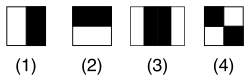</center>

Imos implementar as funcións para calcular cada unha destas características.

In [3]:
def rect_sum(ii, top, left, height, width):
    """
    Calcula a suma dos píxeles dentro dun rectángulo
    usando a imaxe integral `ii`.
    
    Asúmese que `ii` ten a mesma forma que a imaxe (sen fila/columna extra do padding),
    tal e como devolve a función skimage.transform.integral_image.
    """
    bottom = top + height - 1
    right = left + width - 1

    total = ii[bottom, right]
    if top > 0:
        total -= ii[top - 1, right]
    if left > 0:
        total -= ii[bottom, left - 1]
    if top > 0 and left > 0:
        total += ii[top - 1, left - 1]
    return total

def haar_two_rectangle_horizontal(ii, top, left, width, height):
    """
    Característica Haar de 2 rectángulos horizontais:
    [ White | Black ]
    """
    mid = left + width // 2
    white = rect_sum(ii, top, left, height, width // 2)
    black = rect_sum(ii, top, mid, height, width // 2)
    return black - white  # feature value

def haar_two_rectangle_vertical(ii, top, left, width, height):
    """
    Característica Haar de 2 rectángulos verticais:
        [ Black ]
        [ White ]
    """
    mid = top + height // 2

    black = rect_sum(ii, top, left, height // 2, width)
    white = rect_sum(ii, mid, left, height // 2, width)

    return white - black

def haar_three_rectangle(ii, top, left, width, height):
    """
    Característica Haar de 3 rectángulos horizontais:
    [ White | Black | White ]
    """
    w = width // 3
    white1 = rect_sum(ii, top, left, height, w)
    black  = rect_sum(ii, top, left + w, height, w)
    white2 = rect_sum(ii, top, left + 2*w, height, w)
    return black - (white1 + white2)

def haar_four_rectangle_bw_wb(ii, top, left, width, height):
    """
    Característica Haar de 4 rectángulos:
        [ B | W ]
        [ W | B ]
    """
    w = width // 2
    h = height // 2

    # Top-left = Black
    black1 = rect_sum(ii, top, left, h, w)
    # Top-right = White
    white1 = rect_sum(ii, top, left + w, h, w)
    # Bottom-left = White
    white2 = rect_sum(ii, top + h, left, h, w)
    # Bottom-right = Black
    black2 = rect_sum(ii, top + h, left + w, h, w)
    
    return (white1 + white2) - (black1 + black2)

Ahora imos cargar unha imaxe de exemplo e calcular as características de Haar para diferentes rexións da imaxe.

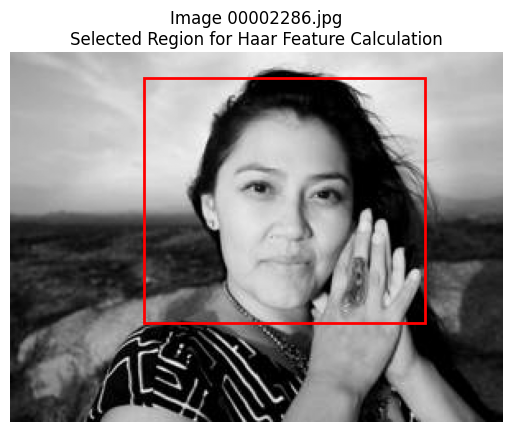

Haar Two-Rectangle Feature: -1087.7333333333308
Haar Two-Rectangle Vertical Feature: -344.6941176470482
Haar Three-Rectangle Feature: -2705.50588235293
Haar Four-Rectangle Feature (BW-WB): -1111.772549019619


In [4]:
from skimage.transform import integral_image
from skimage.color import rgb2gray
import numpy as np

image = Image.open(example_image_path).convert("L")  # Convertemos a escala de grises
image = np.array(image)/255.0
ii = integral_image(image)

# Seleccionamos a bounding box da primeira cara
bbox = example_image_annotations.iloc[0]
top, left = int(bbox["y0"]), int(bbox["x0"])
width = int(bbox["x1"] - bbox["x0"])
height = int(bbox["y1"] - bbox["y0"])

plt.imshow(image, cmap='gray')
plt.gca().add_patch(plt.Rectangle((left, top), width, height,
                                  fill=False, color='red', linewidth=2))
plt.title(f"Image {example_image_path.name}\nSelected Region for Haar Feature Calculation")
plt.axis('off')
plt.show()

feature_1 = haar_two_rectangle_horizontal(ii, top, left, width, height)
feature_2 = haar_two_rectangle_vertical(ii, top, left, width, height)
feature_3 = haar_three_rectangle(ii, top, left, width, height)
feature_4 = haar_four_rectangle_bw_wb(ii, top, left, width, height)

print("Haar Two-Rectangle Feature:", feature_1)
print("Haar Two-Rectangle Vertical Feature:", feature_2)
print("Haar Three-Rectangle Feature:", feature_3)
print("Haar Four-Rectangle Feature (BW-WB):", feature_4)

In [5]:
# Dividir o conxunto de datos en train e test

train_ratio = 0.8 # 20% para test
images_train = np.random.choice(images_list, size=int(len(images_list)*train_ratio), replace=False)
annotations_train = annotations[annotations["image_name"].isin([img.name for img in images_train])]
images_test = list(set(images_list) - set(images_train))
annotations_test = annotations[annotations["image_name"].isin([img.name for img in images_test])]

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from skimage.transform import resize
import numpy as np


def non_max_suppression(detections, overlapThresh=0.4):
    """
    Combina bounding boxes solapadas
    
    Args:
        detections: Diccionario que conten unha lista de bounding boxes (x0, y0, x1, y1) e os seus scores.
        overlapThresh: Limiar para a Intersección sobre a Unión (IoU) para combinar bounding boxes.
    """
    if len(detections) == 0:
        return {}
    
    boxes = detections["bboxes"]

    if boxes.dtype.kind == "i":
        boxes = boxes.astype("float")

    pick = []
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    
    # Ordenar as bounding boxes pola coordenada y da esquina inferior dereita
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        # Calcular a intersección
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        # Calcular o solapamento
        overlap = (w * h) / area[idxs[:last]]

        # Eliminar índices que se solapan significativamente
        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlapThresh)[0])))

    # Converter as caixas a enteiros, e devolver o dicionario resultante
    res_dict = {"bboxes": boxes[pick].astype("int"), "scores": detections["scores"][pick]}

    return res_dict



class ViolaJonesDetector:
    """
    Detector de obxectos Viola-Jones.
    
    Compoñentes clve:
    1. Características Haar: Usa as funcións auxiliares definidas nas celdas anteriores.
    2. Imaxe integral: Para o cálculo rápido das características.
    3. AdaBoost: Actúa de clasificador para determinar se unha rexión (bounding box) contén o obxecto buscado.
    4. Ventá deslizante: Para detectar obxectos en diferentes localizacións e escalas.
    """
    
    def __init__(self, window_size=(24, 24), n_estimators=20, n_features=100):
        """
        Inicializa o detector.
        
        Args:
            window_size: O tamaño fixo da ventá (h, w) á que se redimensionan os parches de imaxe para a clasificación.
            n_estimators: Número de clasificadores débiles en AdaBoost.
            n_features: Número de características Haar aleatorias para xerar o conxunto de características.
        """
        self.window_size = window_size
        self.n_estimators = n_estimators
        
        # Inicializa AdaBoost
        self.clf = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=self.n_estimators
        )
        
        # Xera un conxunto fixo de configuracións de características Haar aleatorias.
        # Nunha implementación completa, avaliaríamos TODAS as posibles características (160k+),
        # pero aquí amosamos un subconxunto para mellorar o rendemento no notebook.
        self.features_config = []
        haar_functions = [
            haar_two_rectangle_horizontal, 
            haar_two_rectangle_vertical, 
            haar_three_rectangle, 
            haar_four_rectangle_bw_wb
        ]
        
        rows, cols = window_size
        for _ in range(n_features):
            func = random.choice(haar_functions)
            # Aleatoriza a posición e o tamaño dentro da ventá, asegurando que non se excede dos límites da imaxe
            w = random.randint(4, cols)
            h = random.randint(4, rows)
            x = random.randint(0, cols - w)
            y = random.randint(0, rows - h)
            # Almacena a configuración: función haar e coordenadas das bounding boxes
            self.features_config.append((func, y, x, w, h))

    def _extract_features(self, ii, off_y=0, off_x=0):
        """
        Extrae as características Haar definidas da imaxe integral `ii`.
        
        Args:
            ii: A imaxe integral.
            off_y, off_x: Desprazamentos aplicados ás coordenadas da característica. 
                          Permite extraer características dunha subventá sen recortar.
        """
        features = []
        for func, y, x, w, h in self.features_config:
            # Calcula o valor da característica usando as funcións auxiliares definidas anteriormente.
            # Engadimos o desprazamento (off_y, off_x) ás coordenadas relativas da característica (y, x).
            val = func(ii, off_y + y, off_x + x, w, h)
            features.append(val)
        return features

    def train(self, images, annotations):
        """
        Prepara o conxunto de datos e adestra o clasificador AdaBoost.
        
        Args:
            images: Lista de rutas de imaxes.
            annotations: DataFrame que contén as caixas delimitadoras.
        """
        print("Preparando conxunto de adestramento...")
        X = []
        y = []
        
        target_h, target_w = self.window_size
        
        for img_path in images:
            # Carga a imaxe e convértea a escala de grises
            try:
                img = Image.open(img_path).convert("L")
                img_arr = np.array(img) / 255.0
            except Exception as e:
                continue
                
            # Obtén a bounding box ground truth para esta imaxe
            ann = annotations[annotations["image_name"] == img_path.name]
            if len(ann) == 0: continue
            
            # --- Exemplo positivo (a cara) ---
            x0, y0, x1, y1 = ann.iloc[0][["x0", "y0", "x1", "y1"]].values.astype(int)
            face_crop = img_arr[y0:y1, x0:x1]
            
            if face_crop.size == 0: continue
            
            # Redimensiona a cara ao tamaño fixo da ventá
            face_resized = resize(face_crop, self.window_size, anti_aliasing=True)
            ii_face = integral_image(face_resized)
            
            # Extrae características (desprazamento 0,0 porque recortamos exactamente a cara)
            X.append(self._extract_features(ii_face))
            y.append(1) # Etiqueta 1 para a clase "cara"
            
            # --- Exemplo negativo (fondo) ---
            # Extrae un recorte aleatorio que non se solape significativamente coa cara
            h_img, w_img = img_arr.shape
            
            # Intenta atopar un recorte negativo válido
            for _ in range(2): 
                rw = random.randint(target_w, min(w_img, h_img)//2)
                rh = int(rw * (target_h/target_w)) # Mantén a relación de aspecto aproximadamente similar á ventá
                
                rx = random.randint(0, w_img - rw)
                ry = random.randint(0, h_img - rh)
                
                # Comprobación para asegurar que o centro do recorte aleatorio non está dentro da caixa da cara
                cx, cy = rx + rw/2, ry + rh/2
                if not (x0 < cx < x1 and y0 < cy < y1):
                    neg_crop = img_arr[ry:ry+rh, rx:rx+rw]
                    neg_resized = resize(neg_crop, self.window_size, anti_aliasing=True)
                    ii_neg = integral_image(neg_resized)
                    X.append(self._extract_features(ii_neg))
                    y.append(0) # Etiqueta 0 para o fondo (clase "non cara")
                    break
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Adestrando AdaBoost con {len(X)} mostras ({np.sum(y)} positivas e {len(y) - np.sum(y)} negativas)...")
        self.clf.fit(X, y)
        print("Adestramento completo.")

    def detect(self, image_path, scale_factor=1.2, step_size=10, non_max_suppression_thresh=0.3):
        """
        Detecta caras nunha imaxe usando unha ventá deslizante e unha pirámide de imaxe (múltiples resolucións).
        
        Args:
            image_path: Ruta á imaxe.
            scale_factor: Ratio de reducción da imaxe en cada nivel da pirámide.
            step_size: Cantidade de píxeles a saltar durante a ventá deslizante (stride).
        """
        img = Image.open(image_path).convert("L")
        img_arr = np.array(img) / 255.0
        
        detections = []
        
        # --- Pirámide de imaxe e ventá deslizante ---
        current_scale = 1.0
        h, w = img_arr.shape
        win_h, win_w = self.window_size
        
        # Bucle mentres a imaxe escalada é máis grande que a ventá de detección
        while int(h / current_scale) > win_h and int(w / current_scale) > win_w:
            
            # Redimensiona a imaxe á escala actual (reducción)
            scaled_h = int(h / current_scale)
            scaled_w = int(w / current_scale)
            
            scaled_img = resize(img_arr, (scaled_h, scaled_w), anti_aliasing=True)
            
            # Calcula a imaxe integral UNHA VEZ para toda a imaxe escalada
            ii_scaled = integral_image(scaled_img)
            
            # Ventá deslizante sobre a imaxe escalada
            for y in range(0, scaled_h - win_h, step_size):
                for x in range(0, scaled_w - win_w, step_size):
                    
                    # Extrae as características Haar eficientemente desde a imaxe integral usando desprazamentos
                    features = self._extract_features(ii_scaled, off_y=y, off_x=x)
                    
                    # Predición usando o clasificador adestrado
                    prediction = self.clf.predict_proba([features])[0]
                    detected_bboxes = []
                    scores = []
                    
                    if prediction[1] > 0.5: # Limiar de detección
                        # Mapea as coordenadas de volta ao tamaño orixinal da imaxe
                        orig_x = int(x * current_scale)
                        orig_y = int(y * current_scale)
                        orig_w = int(win_w * current_scale)
                        orig_h = int(win_h * current_scale)
                        detected_bboxes.append([orig_x, orig_y, orig_x + orig_w, orig_y + orig_h])
                        scores.append(prediction[1])
            
            current_scale *= scale_factor

        if len(detected_bboxes) == 0:
            return {}

        detections = {"bboxes": np.array(detected_bboxes), "scores": np.array(scores)}
            
        # Aplica Non-Maximum Suppression para combinar as bounding boxes solapadas
        final_detections = non_max_suppression(detections, overlapThresh=non_max_suppression_thresh)
        return final_detections

Ahora adestraremos o detector Viola-Jones no conxunto de adestramento

In [7]:
# Instanciamos o detector. Utilizamos un número pequeno de estimadores e características para a velocidade de demostración.
vj_detector = ViolaJonesDetector(n_estimators=10, n_features=50) 

# Adestramos o detector
vj_detector.train(images_train, annotations_train)

Preparando conxunto de adestramento...
Adestrando AdaBoost con 471 mostras (276 positivas e 195 negativas)...
Adestramento completo.


Ahora imos avaliar o detector Viola-Jones nunha imaxe aleatoria do noso conxunto de test.

Imaxe cargada: 00002786.jpg
Detectada(s) 1 cara(s).


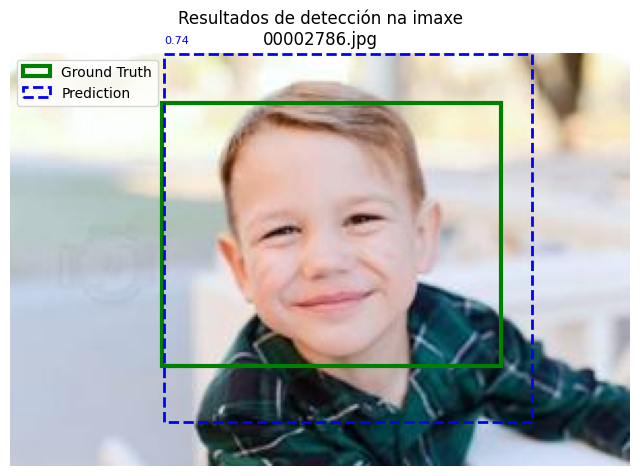

In [8]:

# Cargamos unha imaxe aleatoria do conxunto de test
test_image_path = random.choice(images_test)
print(f"Imaxe cargada: {test_image_path.name}")
detections = vj_detector.detect(test_image_path, scale_factor=1.2, step_size=10)
print(f"Detectada(s) {len(detections.get('bboxes', []))} cara(s).")

# Visualizamos os resultados
fig, ax = plt.subplots(1, figsize=(8, 8))
img = Image.open(test_image_path)
ax.imshow(img)

# Representamos en verde o ground truth
gt_ann = annotations_test[annotations_test["image_name"] == test_image_path.name]
if len(gt_ann) > 0:
    x0, y0, x1, y1 = gt_ann.iloc[0][["x0", "y0", "x1", "y1"]]
    rect_gt = plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, color='green', linewidth=3, label='Ground Truth')
    ax.add_patch(rect_gt)

# Representamos en azul as deteccións, se as hai. Representamos tamén a puntuación de confianza (score).
if detections:
    for i, (x0, y0, x1, y1) in enumerate(detections["bboxes"]):
        rect_pred = plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, color='blue', linewidth=2, linestyle='--', label='Prediction')
        ax.add_patch(rect_pred)
        ax.text(x0, y0 - 5, f"{detections['scores'][i]:.2f}", color='blue', fontsize=8, backgroundcolor='white')

# Hai que manexas as etiquetas duplicadas na lenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title(f"Resultados de detección na imaxe\n{test_image_path.name}")
plt.axis('off')
plt.show()

## Detector HOG (Histogram of Oriented Gradients) + SVM (Support Vector Machine)

O detector HOG + SVM é outro método clásico para a detección de obxectos. O esquema é similar ao de Viola-Jones. Utilízase un descriptor (neste caso HOG, que captura a información de gradientes orientados nunha imaxe) e posteriormente un clasificador (neste caso un SVM) para clasificar as rexións da imaxe como contedoras ou non do obxecto de interese.

In [9]:
from sklearn.svm import LinearSVC
from skimage.transform import resize
import numpy as np
from PIL import Image
import random

import matplotlib.pyplot as plt

# Función para extraer características HOG dunha imaxe ou recorte
def extract_hog_features(image, target_size=(32, 32)):
    """
    Redimensiona a imaxe e calcula o descritor HOG.
    """
    # Redimensionamos a imaxe ao tamaño da ventá de detección
    resized_img = resize(image, target_size, anti_aliasing=True)
    
    # Calculamos os gradientes (magnitude e orientación)
    gx = np.zeros(resized_img.shape)
    gy = np.zeros(resized_img.shape)
    gx[:, :-1] = np.diff(resized_img, n=1, axis=1)
    gy[:-1, :] = np.diff(resized_img, n=1, axis=0)
    
    magnitude = np.sqrt(gx**2 + gy**2)
    orientation = np.arctan2(gy, gx) * (180 / np.pi) % 180
    
    # Obtemos o histograma de orientacións por celdas (8x8 pixeles)
    cell_size = 8
    n_cells_x = target_size[1] // cell_size
    n_cells_y = target_size[0] // cell_size
    n_bins = 9
    
    hog_cells = np.zeros((n_cells_y, n_cells_x, n_bins))
    
    for i in range(n_cells_y):
        for j in range(n_cells_x):
            cell_mag = magnitude[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            cell_ori = orientation[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            
            for bin_idx in range(n_bins):
                # Rango de ángulos para este bin (ao ser 9 bins, imos de 20 en 20 graos: 0-20, 20-40, etc.)
                bin_range_min = bin_idx * (180 / n_bins)
                bin_range_max = (bin_idx + 1) * (180 / n_bins)
                
                # Máscara para píxeles que caen neste bin
                mask = (cell_ori >= bin_range_min) & (cell_ori < bin_range_max)
                hog_cells[i, j, bin_idx] = np.sum(cell_mag[mask])
                
    # Normalización por bloques de 2x2 celdas
    block_size = 2
    n_blocks_y = n_cells_y - block_size + 1
    n_blocks_x = n_cells_x - block_size + 1
    normalized_blocks = []
    
    epsilon = 1e-5
    
    for i in range(n_blocks_y):
        for j in range(n_blocks_x):
            block = hog_cells[i:i+block_size, j:j+block_size, :]
            # Aplanamos e aplicamos unha normalización L2
            block_vector = block.flatten()
            norm = np.sqrt(np.sum(block_vector**2) + epsilon**2)
            normalized_blocks.append(block_vector / norm)
            
    return np.concatenate(normalized_blocks)

class HOGSVMDetector:
    """
    Detector de obxectos simple baseado en HOG + SVM.
    """
    def __init__(self, window_size=(24, 24)):
        self.window_size = window_size
        # Usamos LinearSVC, que é eficiente para clasificación con HOG
        self.clf = LinearSVC(random_state=42, max_iter=2000)

    def train(self, images, annotations):
        print("Preparando conxunto de adestramento HOG...")
        X = []
        y = []
        target_h, target_w = self.window_size

        for img_path in images:
            try:
                # Cargar imaxe e converter a escala de grises
                img = Image.open(img_path).convert("L")
                img_arr = np.array(img) / 255.0
            except Exception:
                continue

            # Obter anotacións para a imaxe actual
            ann = annotations[annotations["image_name"] == img_path.name]
            if len(ann) == 0: continue

            # Exemplo positivo (a cara)
            x0, y0, x1, y1 = ann.iloc[0][["x0", "y0", "x1", "y1"]].values.astype(int)
            face_crop = img_arr[y0:y1, x0:x1]
            
            if face_crop.size == 0: continue
            
            # Extraer características HOG do recorte da cara
            X.append(extract_hog_features(face_crop, self.window_size))
            y.append(1) # Clase 1: Cara

            # Exemplo negativo (fondo ou clase "non cara")
            h_img, w_img = img_arr.shape
            # Intentamos obter un recorte aleatorio que non sexa a cara
            for _ in range(2): 
                rw = random.randint(target_w, min(w_img, h_img)//2)
                rh = int(rw * (target_h/target_w))
                
                rx = random.randint(0, w_img - rw)
                ry = random.randint(0, h_img - rh)
                
                cx, cy = rx + rw/2, ry + rh/2
                # Comprobamos que o centro do recorte non cae dentro da cara
                if not (x0 < cx < x1 and y0 < cy < y1):
                    neg_crop = img_arr[ry:ry+rh, rx:rx+rw]
                    X.append(extract_hog_features(neg_crop, self.window_size))
                    y.append(0) # Clase 0: Fondo (non cara)
                    break
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Adestrando SVM con {len(X)} mostras...")
        self.clf.fit(X, y)
        print("Adestramento completo.")

    def detect(self, image_path, scale_factor=1.2, step_size=10, non_max_suppression_thresh=0.3):
        """
        Detecta caras usando pirámide de imaxes e ventá deslizante.
        """
        img = Image.open(image_path).convert("L")
        img_arr = np.array(img) / 255.0
        
        detections = []
        scores = []
        
        current_scale = 1.0
        h, w = img_arr.shape
        win_h, win_w = self.window_size
        
        # Bucle da pirámide de imaxe
        while int(h / current_scale) > win_h and int(w / current_scale) > win_w:
            scaled_h = int(h / current_scale)
            scaled_w = int(w / current_scale)
            scaled_img = resize(img_arr, (scaled_h, scaled_w), anti_aliasing=True)
            
            # Ventá deslizante
            for y in range(0, scaled_h - win_h, step_size):
                for x in range(0, scaled_w - win_w, step_size):
                    # Recorte da ventá actual
                    window = scaled_img[y:y+win_h, x:x+win_w]
                    
                    # Extraer características e predicir
                    features = extract_hog_features(window, self.window_size)
                    # decision_function devolve a confianza (distancia ao hiperplano)
                    score = self.clf.decision_function([features])[0]
                    if score > 1: # Limiar de detección
                        # Mapear coordenadas á escala orixinal
                        orig_x = int(x * current_scale)
                        orig_y = int(y * current_scale)
                        orig_w = int(win_w * current_scale)
                        orig_h = int(win_h * current_scale)
                        detections.append([orig_x, orig_y, orig_x + orig_w, orig_y + orig_h])
                        scores.append(score)
            
            current_scale *= scale_factor

        if len(detections) == 0:
            return {}

        # Aplicar Non-Maximum Suppression (NMS) para eliminar duplicados
        det_dict = {"bboxes": np.array(detections), "scores": np.array(scores)}
        return non_max_suppression(det_dict, overlapThresh=non_max_suppression_thresh)

Ahora adestramos o detector HOG + SVM no conxunto de adestramento

In [10]:
hog_detector = HOGSVMDetector(window_size=(32, 32))
hog_detector.train(images_train, annotations_train)

Preparando conxunto de adestramento HOG...
Adestrando SVM con 472 mostras...
Adestramento completo.


E probamos o detector adestrado nunha imaxe aleatoria do conxunto de test.

Probando na imaxe: 00001124.jpg


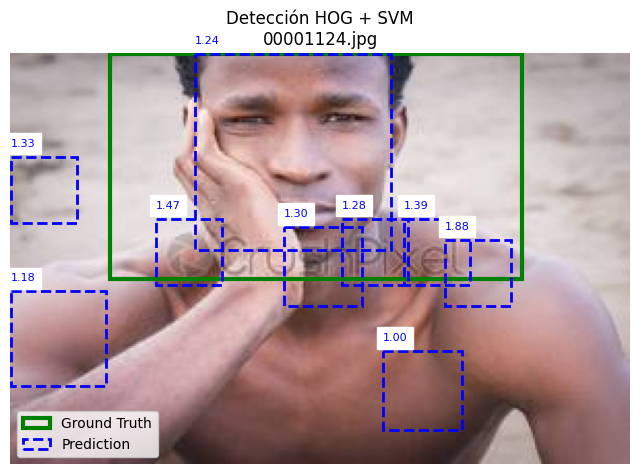

In [11]:
test_image_path = random.choice(images_test)
print(f"Probando na imaxe: {test_image_path.name}")
detections = hog_detector.detect(test_image_path, scale_factor=1.2, step_size=10)

# Visualizamos os resultados
fig, ax = plt.subplots(1, figsize=(8, 8))
img = Image.open(test_image_path)
ax.imshow(img)

# Representamos o Ground Truth (verde)
gt_ann = annotations_test[annotations_test["image_name"] == test_image_path.name]
if len(gt_ann) > 0:
    x0, y0, x1, y1 = gt_ann.iloc[0][["x0", "y0", "x1", "y1"]]
    ax.add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, color='green', linewidth=3, label='Ground Truth'))

# Representamos as deteccións (azul)
if detections:
    for i, (x0, y0, x1, y1) in enumerate(detections["bboxes"]):
        score = detections["scores"][i]
        ax.add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, color='blue', linewidth=2, linestyle='--', label='Prediction'))
        ax.text(x0, y0 - 5, f"{score:.2f}", color='blue', fontsize=8, backgroundcolor='white')

# Lenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.axis('off')
plt.title(f"Detección HOG + SVM\n{test_image_path.name}")
plt.show()

## Comparación e optimización dos detectores

Nesta sección imos obter datos cuantitativos para comparar o rendemento dos dous detectores clásicos que implementamos: Viola-Jones e HOG + SVM. Ademais, imos explorar como axustar os hiperparámetros de cada detector para optimizar o seu rendemento.

Primeiro, imos definir unha función para cacular o mAP (mean Average Precision) dun detector nun conxunto de test. O mAP é unha métrica comúnmente empregada para avaliar o rendemento dos detectores de obxectos.

In [12]:
from sklearn.metrics import average_precision_score
import numpy as np

def calculate_iou(boxA, boxB):
    """
    Calcula a Intersección sobre a Unión (IoU) entre dúas bounding boxes.
    boxA, boxB: [x0, y0, x1, y1]
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def evaluate_detector(detector, images, annotations, iou_threshold=0.5, scale_factor=1.2, step_size=10, non_max_suppression_thresh=0.3):
    """
    Avalía o detector nun conxunto de imaxes e calcula a AP para un limiar de IoU dado.
    """
    true_positives = []
    scores = []
    n_ground_truths = 0

    for img_path in images:
        # Obter ground truth
        gt_ann = annotations[annotations["image_name"] == img_path.name]
        gt_boxes = gt_ann[["x0", "y0", "x1", "y1"]].values
        n_ground_truths += len(gt_boxes)
        
        # Obter predicións
        detections = detector.detect(img_path, scale_factor=scale_factor, step_size=step_size, non_max_suppression_thresh=non_max_suppression_thresh)
        
        if not detections:
            continue
            
        pred_boxes = detections["bboxes"]
        pred_scores = detections["scores"]
        
        # Para cada imaxe, emparellar predicións co ground truth
        # Ordenar predicións por score descendente
        sorted_indices = np.argsort(-pred_scores)
        pred_boxes = pred_boxes[sorted_indices]
        pred_scores = pred_scores[sorted_indices]
        
        # Levamos a conta dos ground truths xa emparellados (inicialmente ningún)
        gt_matched = np.zeros(len(gt_boxes), dtype=bool)
        
        for i, pred_box in enumerate(pred_boxes):
            scores.append(pred_scores[i])
            
            if len(gt_boxes) == 0:
                true_positives.append(0)
                continue
                
            # Calcular IoU con todas as GT boxes
            ious = [calculate_iou(pred_box, gt_box) for gt_box in gt_boxes]
            max_iou_idx = np.argmax(ious)
            max_iou = ious[max_iou_idx]
            
            if max_iou >= iou_threshold:
                if not gt_matched[max_iou_idx]:
                    true_positives.append(1)
                    gt_matched[max_iou_idx] = True
                else:
                    true_positives.append(0) # Falso positivo (este obxecto xa foi detectado)
            else:
                true_positives.append(0) # Falso positivo (IoU baixo)

    # Converter a arrays numpy
    scores = np.array(scores)
    true_positives = np.array(true_positives)
    
    # Se non hai ground truths ou non hai predicións ou non hai acertos, AP é 0
    if n_ground_truths == 0 or len(scores) == 0 or np.sum(true_positives) == 0:
        return 0.0
    
    # Calculamos a área baixo a curva Precision-Recall.
    ap = average_precision_score(true_positives, scores)
    # Axustamos o resultado porque average_precision_score asume que o recall máximo é 1 (todos os positivos atopados),
    # pero no noso caso o recall máximo é (TPs atopados / Total GTs).
    ap = ap * (np.sum(true_positives) / n_ground_truths)
    
    return ap

def calculate_map_metrics(detector, images_test, annotations_test, scale_factor=1.2, step_size=10, non_max_suppression_thresh=0.3):
    """
    Calcula mAP@0.5, mAP@0.75 e mAP@0.5-0.95.
    """

    # TODO
    
    return {
        "mAP@0.5": None,
        "mAP@0.75": None,
        "mAP@0.5:0.95": None
    }

## Exercicio proposto

1. Implementa a función anterior para calcular o mAP dun detector de obxectos no conxunto de test:
- mAP@0.5: supoñendo que a detección é correcta se se solapa coa bounding box verdadeira nun 50% (IoU >= 0.5).
- mAP@0.75: supoñendo que a detección é correcta se se solapa coa bounding box verdadeira nun 75% (IoU >= 0.75).
- mAP@0.5:0.95: supoñendo que a detección é correcta se se solapa coa bounding box verdadeira nun rango de 50% a 95% (IoU >= 0.5, 0.55, ..., 0.95).

2. Emprega esta función para calcular o mAP dos detectores Viola-Jones e HOG + SVM no conxunto de test. Selecciona un subconxunto de imaxes do conxunto de test para realizar a avaliación, e compara os resultados obtidos polos dous detectores. Proba a variar os parámetros dos detectores (por exemplo, o tamaño da ventá deslizante, o umbral do Non-Maximum Suppression, etc.) para optimizar o seu rendemento e observa como afecta isto ao mAP.

3. Proba outros modelos de detección baseados en Deep Learning (YOLO, Faster R-CNN, etc.)

## Apartado 1